# Phase 2a: Unsupervised Learning (HCC1806)

**Datasets:** Smart-seq train (3000 genes × 182 cells) and Drop-seq train (3000 genes × 14,682 cells), both normalised.

**Goal:** explore the structure of the data **without using the condition labels**. We will (a) see whether hypoxia vs normoxia separates spontaneously, (b) check for batch / sub-population structure, and (c) compare how the two technologies organise the same biology.

**Methods:**
1. log₂(x+1) + standardisation
2. PCA — scree, scatter by condition, scatter by plate (Smart-seq), top loadings
3. t-SNE and UMAP
4. K-means (k=2) with ARI / NMI; silhouette over k
5. Ward hierarchical clustering (Smart-seq only — too expensive for Drop-seq's 14k cells)
6. Cross-technology comparison: PC1-gene overlap, log-fold-change concordance, hypoxia markers

**Note on labels:** clustering is unsupervised: we don't pass `y` to the algorithm. We use the labels *afterwards* to score the result (ARI, NMI). This is standard practice when labels happen to be available.

## 0. Setup

In [18]:
import re, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

try:
    import umap.umap_ as umap
    HAS_UMAP = True
except Exception:
    HAS_UMAP = False
    print('UMAP not installed — run `pip install umap-learn` to enable UMAP cells.')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

SS_DIR = Path('/Users/nicolasrazzotti/Downloads/AI LAB/SmartSeq')
DS_DIR = Path('/Users/nicolasrazzotti/Downloads/AI LAB/DropSeq')

FILES = {
    'SS_train': SS_DIR / 'HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt',
    'SS_meta':  SS_DIR / 'HCC1806_SmartS_MetaData.tsv',
    'DS_train': DS_DIR / 'HCC1806_Filtered_Normalised_3000_Data_train.txt',
}

OUTDIR = Path('phase2_outputs')
OUTDIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
PALETTE = {'Hypoxia': '#d62728', 'Normoxia': '#1f77b4'}
print('Plots saved to:', OUTDIR.resolve())

Plots saved to: /Users/nicolasrazzotti/Downloads/AI LAB/phase2_outputs


In [2]:
# Helper functions
def load(path):
    df = pd.read_csv(path, sep=r'\s+', index_col=0, engine='python')
    df.columns = df.columns.str.replace('"', '').str.strip()
    df.index = df.index.astype(str).str.replace('"', '').str.strip()
    return df

def condition_of(name):
    s = name.lower()
    if re.search(r'hypo', s): return 'Hypoxia'
    if re.search(r'norm', s): return 'Normoxia'
    return 'Unknown'

def conditions(df):
    return np.array([condition_of(c) for c in df.columns])

def prepare(df):
    """log2(x+1), transpose to (cells, genes), standardise."""
    X_log = np.log2(df + 1).T.values
    X_scaled = StandardScaler().fit_transform(X_log)
    return X_scaled

---
# Part A — Smart-seq HCC1806

## 1. Load, preprocess, and check batch balance

In [3]:
ss = load(FILES['SS_train'])
ss_meta = pd.read_csv(FILES['SS_meta'], sep='\t')
y_ss = conditions(ss)
X_ss = prepare(ss)

print(f'Shape (cells × genes): {X_ss.shape}')
print(f'Conditions: {pd.Series(y_ss).value_counts().to_dict()}')

# Join cells to metadata to get plate info
meta_idx = ss_meta.set_index('Filename')
ss_plate = pd.Series(
    [str(meta_idx.loc[c, 'PCR Plate']) if c in meta_idx.index else 'NA' for c in ss.columns],
    index=ss.columns, name='Plate'
)
print(f'\nPCR plates: {ss_plate.value_counts().to_dict()}')
print('\nPlate × Condition crosstab (check for batch confounding):')
print(pd.crosstab(ss_plate, pd.Series(y_ss, index=ss.columns)))

Shape (cells × genes): (182, 3000)
Conditions: {'Hypoxia': 97, 'Normoxia': 85}

PCR plates: {'3': 63, '2': 59, '4': 47, '1': 13}

Plate × Condition crosstab (check for batch confounding):
col_0  Hypoxia  Normoxia
Plate                   
1            8         5
2           33        26
3           36        27
4           20        27


**What we're checking:** if one plate is mostly hypoxia and another mostly normoxia, any clustering result could be picking up plate effects (different lab session, batch of reagents) rather than the biology. Ideally every plate has a mix of both conditions.

## 2. PCA — scree plot

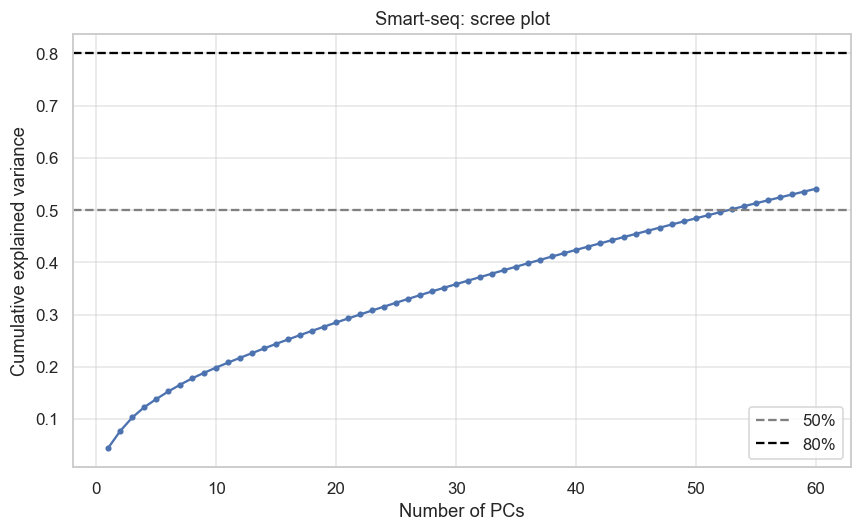

PC1: 4.5%, PC2: 3.2%, PC3: 2.6%
PCs needed for 50% variance: 53
PCs needed for 80% variance: 117


In [4]:
pca_ss = PCA(random_state=RANDOM_STATE).fit(X_ss)
ev = pca_ss.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, 61), np.cumsum(ev[:60]), marker='o', markersize=3)
plt.axhline(0.5, color='gray', linestyle='--', label='50%')
plt.axhline(0.8, color='black', linestyle='--', label='80%')
plt.xlabel('Number of PCs'); plt.ylabel('Cumulative explained variance')
plt.title('Smart-seq: scree plot')
plt.legend(); plt.tight_layout(); plt.savefig(OUTDIR / 'ss_01_scree.png', dpi=150); plt.show()

print(f'PC1: {ev[0]*100:.1f}%, PC2: {ev[1]*100:.1f}%, PC3: {ev[2]*100:.1f}%')
print(f'PCs needed for 50% variance: {(np.cumsum(ev) >= 0.5).argmax() + 1}')
print(f'PCs needed for 80% variance: {(np.cumsum(ev) >= 0.8).argmax() + 1}')

**Reading the scree:** PC1 alone captures only a small fraction (~5%) of the variance - there's no single dominant axis. About 100 PCs are needed to reach 80%, meaning the data is intrinsically high-dimensional. We'll use the top 50 PCs as input to t-SNE and clustering (standard scRNA-seq practice: denoises and speeds up downstream steps).

## 3. PCA scatter — coloured by condition and by plate

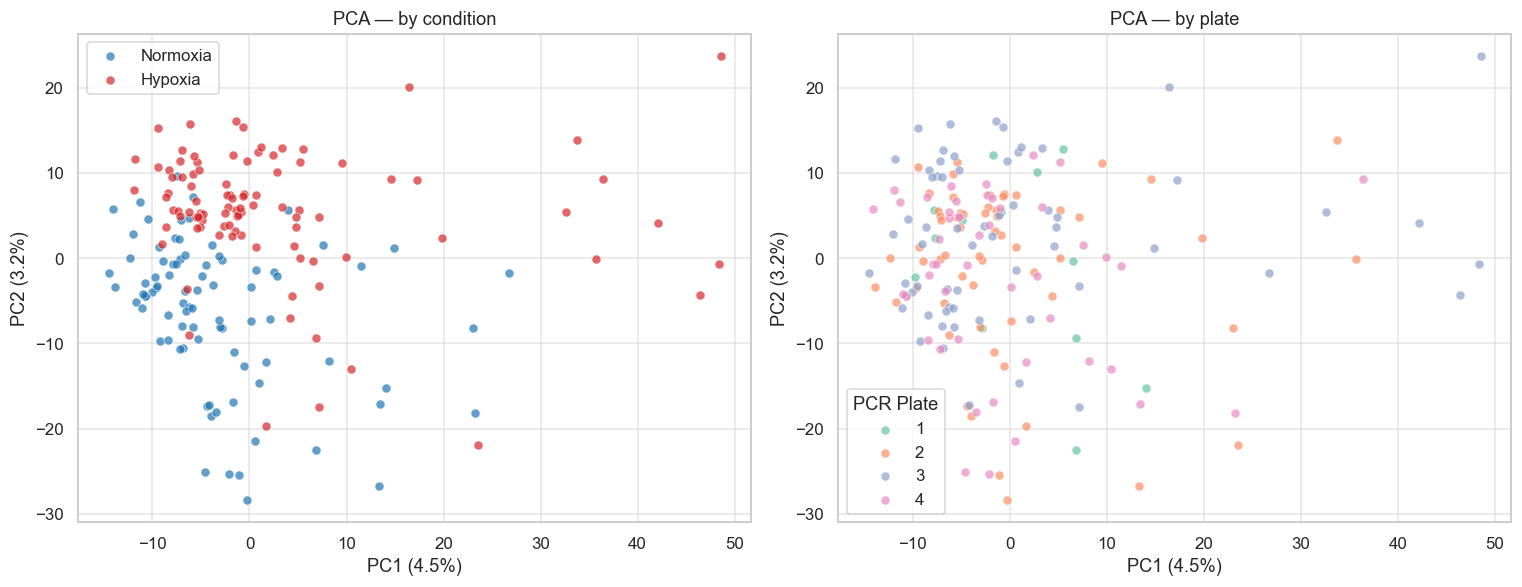

In [5]:
proj_ss = pca_ss.transform(X_ss)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# By condition
for c in ['Normoxia', 'Hypoxia']:
    mask = y_ss == c
    axes[0].scatter(proj_ss[mask, 0], proj_ss[mask, 1], c=PALETTE[c], label=c,
                    s=35, alpha=0.7, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({ev[0]*100:.1f}%)'); axes[0].set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
axes[0].set_title('PCA — by condition'); axes[0].legend()

# By plate
plate_colors = sns.color_palette('Set2', n_colors=ss_plate.nunique())
for i, p in enumerate(sorted(ss_plate.unique())):
    mask = ss_plate.values == p
    axes[1].scatter(proj_ss[mask, 0], proj_ss[mask, 1], c=[plate_colors[i]], label=p,
                    s=35, alpha=0.7, edgecolors='white', linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({ev[0]*100:.1f}%)'); axes[1].set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
axes[1].set_title('PCA — by plate'); axes[1].legend(title='PCR Plate')

plt.tight_layout(); plt.savefig(OUTDIR / 'ss_02_pca_scatter.png', dpi=150); plt.show()

**How to read this:**
- If the condition-coloured panel shows two distinct clouds → PC1/PC2 captures the hypoxia signal. If not → the dominant variance axis is something else.
- If the plate-coloured panel shows the plates as separate clusters → there's a batch effect. This is critical to check before trusting any clustering result.
- In HCC1806 we expect PC1/PC2 to be dominated by **cell-subtype heterogeneity** rather than hypoxia (since the 24h hypoxia exposure is a smaller signal than the cell-to-cell variation in this triple-negative line). We'll confirm by looking at the gene loadings next.

## 4. PCA loadings — which genes drive PC1?

In [6]:
MARKERS = {'DDIT4','ANGPTL4','NDRG1','EGLN3','CA9','BNIP3','SLC2A1','VEGFA','PDK1','LDHA','HK2','PFKFB3','P4HA1','P4HA2','LOX','MXI1'}

loadings_ss = pd.DataFrame(pca_ss.components_[:5].T, index=ss.index,
                           columns=['PC1','PC2','PC3','PC4','PC5'])

top_pc1 = loadings_ss['PC1'].abs().nlargest(20).index
print('Top 20 genes by |PC1| loading:')
print(loadings_ss.loc[top_pc1, ['PC1']].round(3))
print(f'\nHypoxia markers in top-20 PC1: {set(top_pc1) & MARKERS}')

# Try lower PCs too — if PC1 is not hypoxia, maybe PC3 or PC4 is
for pc in ['PC2', 'PC3', 'PC4', 'PC5']:
    top = loadings_ss[pc].abs().nlargest(20).index
    n_markers = len(set(top) & MARKERS)
    print(f'{pc}: {n_markers} hypoxia markers in top-20 → {sorted(set(top) & MARKERS)}')

Top 20 genes by |PC1| loading:
            PC1
KRT13     0.070
PRSS23   -0.069
MUC16     0.068
LY6D      0.067
CD44     -0.067
CTNNAL1  -0.066
TMPRSS4   0.066
KRT4      0.064
CSTB      0.063
SPRR1B    0.063
IVL       0.063
MT2A     -0.063
TMEM200A -0.063
SCEL      0.062
ALDH1A1   0.062
CEACAM6   0.061
GAS6-AS1 -0.061
CEACAM5   0.061
VILL      0.061
SPRR1A    0.061

Hypoxia markers in top-20 PC1: set()
PC2: 3 hypoxia markers in top-20 → ['DDIT4', 'NDRG1', 'PFKFB3']
PC3: 1 hypoxia markers in top-20 → ['BNIP3']
PC4: 2 hypoxia markers in top-20 → ['LDHA', 'SLC2A1']
PC5: 0 hypoxia markers in top-20 → []


**Discussion:** if the top PC1 genes are dominated by keratins (`KRT13, KRT4`), mucins (`MUC16`), and other epithelial markers, PC1 is capturing **epithelial subtype heterogeneity within the HCC1806 population** — not the hypoxia treatment. The hypoxia signal is real but lives on a lower PC (often PC3 or PC4). Scanning across PCs tells us which axis is biology vs which is technical/subtype variation.

## 5. t-SNE and UMAP

Non-linear embeddings often reveal structure that PCA misses, because PCA can only capture *linear* directions of variance.

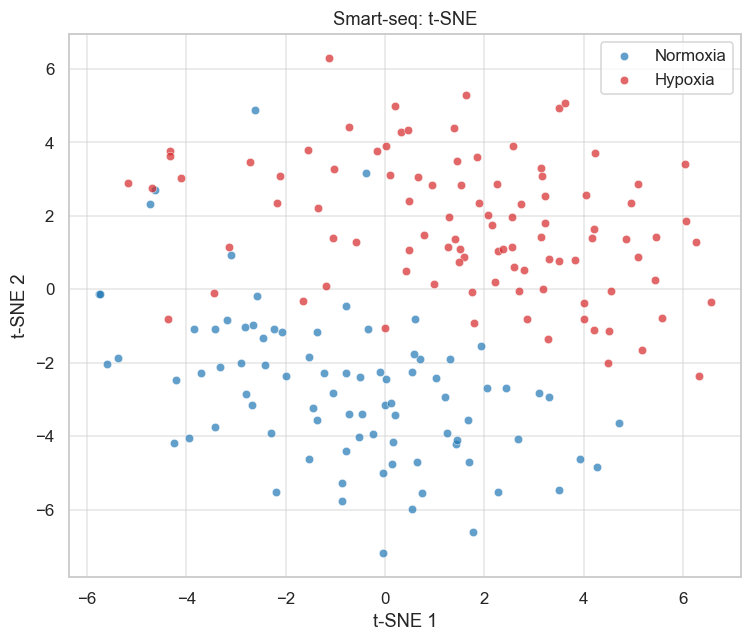

In [7]:
# t-SNE and UMAP on top 50 PCs (standard scRNA-seq workflow)
X_pcs_ss = PCA(n_components=50, random_state=RANDOM_STATE).fit_transform(X_ss)

tsne_ss = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE,
               init='pca', learning_rate='auto').fit_transform(X_pcs_ss)

if HAS_UMAP:
    umap_ss = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        random_state=RANDOM_STATE).fit_transform(X_pcs_ss)

n_plots = 2 if HAS_UMAP else 1
fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 6), squeeze=False)

for c in ['Normoxia', 'Hypoxia']:
    mask = y_ss == c
    axes[0,0].scatter(tsne_ss[mask, 0], tsne_ss[mask, 1], c=PALETTE[c], label=c,
                      s=30, alpha=0.7, edgecolors='white', linewidth=0.4)
axes[0,0].set_title('Smart-seq: t-SNE'); axes[0,0].set_xlabel('t-SNE 1'); axes[0,0].set_ylabel('t-SNE 2')
axes[0,0].legend()

if HAS_UMAP:
    for c in ['Normoxia', 'Hypoxia']:
        mask = y_ss == c
        axes[0,1].scatter(umap_ss[mask, 0], umap_ss[mask, 1], c=PALETTE[c], label=c,
                          s=30, alpha=0.7, edgecolors='white', linewidth=0.4)
    axes[0,1].set_title('Smart-seq: UMAP'); axes[0,1].set_xlabel('UMAP 1'); axes[0,1].set_ylabel('UMAP 2')
    axes[0,1].legend()

plt.tight_layout(); plt.savefig(OUTDIR / 'ss_03_embeddings.png', dpi=150); plt.show()

**Reading:** if hypoxia and normoxia cells separate in t-SNE/UMAP despite not separating in PC1/PC2, it means the signal is non-linear in the original space — but still present. If they intermix in *all* embeddings, the hypoxia signal is too weak to dominate unsupervised structure (which doesn't preclude a supervised classifier finding it later).

## 6. K-means clustering and silhouette

K-means with k=2 — does it recover hypoxia/normoxia? Then a silhouette sweep to see if k=2 is data-supported at all.

Smart-seq K-means (k=2):  ARI = -0.005,  NMI = 0.005
Confusion (true × predicted cluster):
cluster    0   1
true            
Hypoxia   82  15
Normoxia  76   9


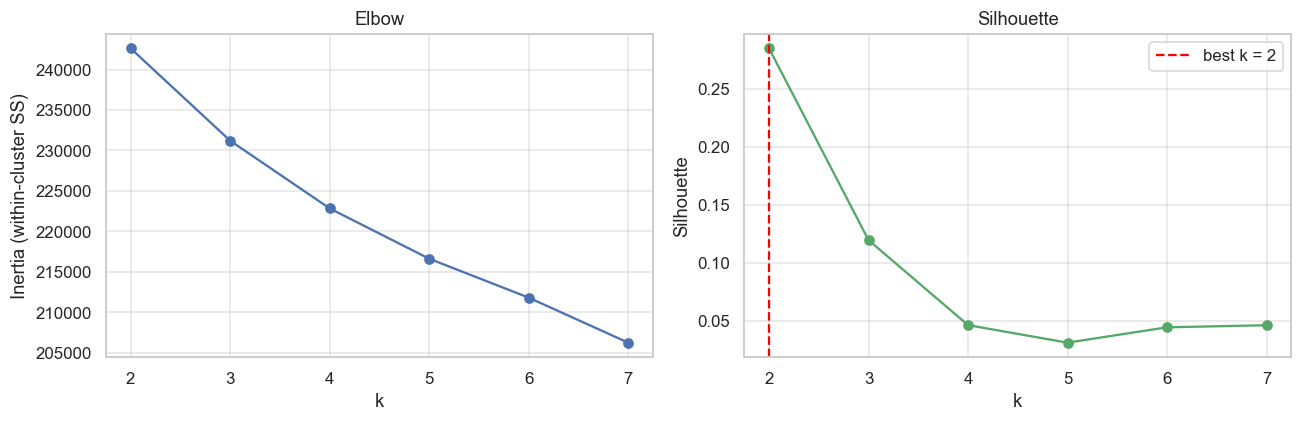

In [8]:
km_ss = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE).fit(X_pcs_ss)
ari = adjusted_rand_score(y_ss, km_ss.labels_)
nmi = normalized_mutual_info_score(y_ss, km_ss.labels_)
cm = pd.crosstab(pd.Series(y_ss, name='true'), pd.Series(km_ss.labels_, name='cluster'))
print(f'Smart-seq K-means (k=2):  ARI = {ari:.3f},  NMI = {nmi:.3f}')
print('Confusion (true × predicted cluster):')
print(cm.to_string())

# Silhouette over k
sils, inertias = [], []
for k in range(2, 8):
    km_k = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_pcs_ss)
    sils.append(silhouette_score(X_pcs_ss, km_k.labels_))
    inertias.append(km_k.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(2, 8), inertias, marker='o')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia (within-cluster SS)'); axes[0].set_title('Elbow')
axes[1].plot(range(2, 8), sils, marker='o', color='C2')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette'); axes[1].set_title('Silhouette')
axes[1].axvline(range(2, 8)[int(np.argmax(sils))], color='red', linestyle='--', label=f'best k = {range(2, 8)[int(np.argmax(sils))]}')
axes[1].legend()
plt.tight_layout(); plt.savefig(OUTDIR / 'ss_04_k_selection.png', dpi=150); plt.show()

**Interpretation of ARI:**
- ARI > 0.7: clustering strongly recovers condition
- ARI ≈ 0: clustering finds a structure unrelated to condition
- ARI < 0: clustering is anti-aligned with condition (very rare)

An ARI near 0 doesn't mean clustering failed — it means k-means found a *different* two-cluster structure, likely the epithelial-subtype split visible in the PCA loadings. The data *does* have two-cluster structure (silhouette peaks at k=2), it's just orthogonal to hypoxia.

**This is an important narrative point for the report:** unsupervised clustering finds the strongest axis of variation, which is not necessarily the axis we care about. Supervised methods, in contrast, use the labels directly and can find the hypoxia signal even when it's not the dominant variance direction.

## 7. Hierarchical clustering (Ward)

Ward (k=2):  ARI = -0.004,  NMI = 0.011


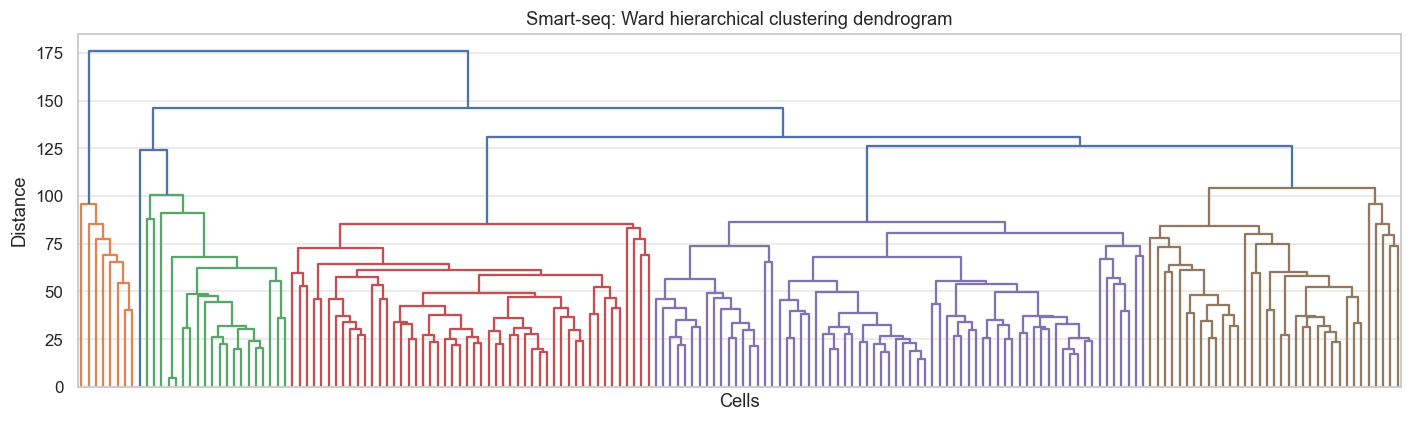

In [9]:
Z = linkage(X_pcs_ss, method='ward')
ward_labels = fcluster(Z, t=2, criterion='maxclust')
ari_w = adjusted_rand_score(y_ss, ward_labels)
nmi_w = normalized_mutual_info_score(y_ss, ward_labels)
print(f'Ward (k=2):  ARI = {ari_w:.3f},  NMI = {nmi_w:.3f}')

plt.figure(figsize=(13, 4))
dendrogram(Z, no_labels=True, color_threshold=Z[-1, 2] * 0.7)
plt.title('Smart-seq: Ward hierarchical clustering dendrogram')
plt.xlabel('Cells'); plt.ylabel('Distance')
plt.tight_layout(); plt.savefig(OUTDIR / 'ss_05_dendrogram.png', dpi=150); plt.show()

**Why two algorithms?** K-means assumes round clusters; Ward minimises within-cluster variance step by step and can find elongated structures. If both algorithms give similar ARI against the condition labels, the result is method-robust.

---
# Part B — Drop-seq HCC1806

Same pipeline, but with two changes for scale:
- t-SNE on a 5,000-cell random subsample (full 14,682 takes too long).
- No Ward hierarchical clustering (full pairwise distance matrix on 14k cells is ~1.5 GB).
- UMAP runs fine on all cells.

## 1. Load and preprocess

In [10]:
ds = load(FILES['DS_train'])
y_ds = conditions(ds)
X_ds = prepare(ds)
print(f'Shape (cells × genes): {X_ds.shape}')
print(f'Conditions: {pd.Series(y_ds).value_counts().to_dict()}')

Shape (cells × genes): (14682, 3000)
Conditions: {'Hypoxia': 8899, 'Normoxia': 5783}


## 2. PCA — scree and scatter

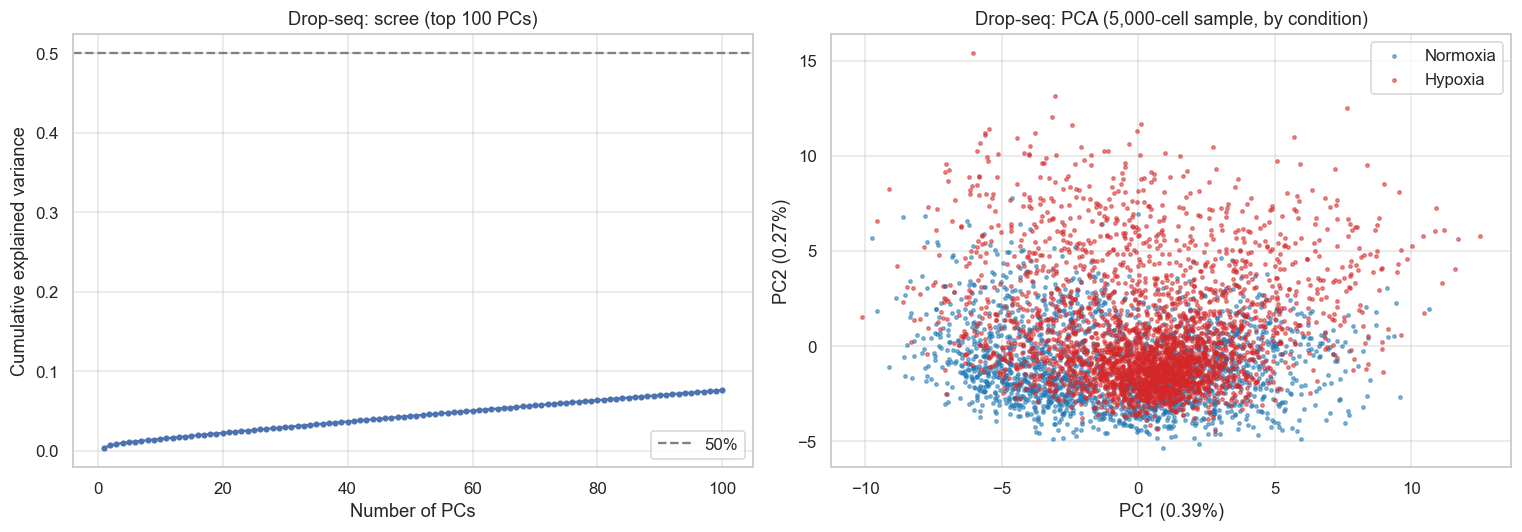

PC1: 0.39%, PC2: 0.27%, PC3: 0.17%


In [11]:
pca_ds = PCA(n_components=100, random_state=RANDOM_STATE).fit(X_ds)
ev_ds = pca_ds.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(np.arange(1, 101), np.cumsum(ev_ds), marker='o', markersize=3)
axes[0].axhline(0.5, color='gray', linestyle='--', label='50%')
axes[0].set_xlabel('Number of PCs'); axes[0].set_ylabel('Cumulative explained variance')
axes[0].set_title('Drop-seq: scree (top 100 PCs)')
axes[0].legend()

proj_ds = pca_ds.transform(X_ds)
# Subsample for plotting (15k points is messy)
rng = np.random.default_rng(42)
plot_idx = rng.choice(len(proj_ds), 5000, replace=False)
for c in ['Normoxia', 'Hypoxia']:
    mask = (y_ds[plot_idx] == c)
    axes[1].scatter(proj_ds[plot_idx][mask, 0], proj_ds[plot_idx][mask, 1],
                    c=PALETTE[c], label=c, s=5, alpha=0.5)
axes[1].set_xlabel(f'PC1 ({ev_ds[0]*100:.2f}%)'); axes[1].set_ylabel(f'PC2 ({ev_ds[1]*100:.2f}%)')
axes[1].set_title('Drop-seq: PCA (5,000-cell sample, by condition)')
axes[1].legend()

plt.tight_layout(); plt.savefig(OUTDIR / 'ds_01_pca.png', dpi=150); plt.show()

print(f'PC1: {ev_ds[0]*100:.2f}%, PC2: {ev_ds[1]*100:.2f}%, PC3: {ev_ds[2]*100:.2f}%')

**Drop-seq PCA observation:** with 97% sparsity, the variance is spread across many dimensions and PC1 captures a tiny fraction of total variance. This is characteristic of sparse high-dimensional data and is a separate problem from "PC1 doesn't match condition" — even in principle, no single direction can dominate when so many cells are mostly zero. This is yet another reason cross-technology transfer is hard.

## 3. PCA loadings

In [12]:
loadings_ds = pd.DataFrame(pca_ds.components_[:5].T, index=ds.index,
                           columns=['PC1','PC2','PC3','PC4','PC5'])

for pc in ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']:
    top = loadings_ds[pc].abs().nlargest(15).index
    n_markers = len(set(top) & MARKERS)
    print(f'{pc}: {n_markers} hypoxia markers in top-15 → {sorted(set(top) & MARKERS) if n_markers else ""}')
    print(f'   top 10: {list(top[:10])}')

PC1: 0 hypoxia markers in top-15 → 
   top 10: ['FTL', 'RPS28', 'RPS5', 'RPS12', 'HSPA5', 'RPL41', 'H1-5', 'RPL35', 'RPLP2', 'RPS19']
PC2: 3 hypoxia markers in top-15 → ['BNIP3', 'NDRG1', 'P4HA1']
   top 10: ['IGFBP3', 'P4HA1', 'AHNAK', 'HSP90B1', 'PDIA3', 'NDRG1', 'ATP1A1', 'AHNAK2', 'DSP', 'HSPA5']
PC3: 0 hypoxia markers in top-15 → 
   top 10: ['AKR1C2', 'AKR1C1', 'BCYRN1', 'HSP90AB1', 'WDR43', 'HSP90AA1', 'H4C3', 'HSPD1', 'EIF3J', 'CALM2']
PC4: 2 hypoxia markers in top-15 → ['LDHA', 'P4HA1']
   top 10: ['P4HA1', 'ENO1', 'H4C3', 'H1-3', 'H1-1', 'PDIA3', 'HSP90B1', 'H1-5', 'LDHA', 'H1-2']
PC5: 0 hypoxia markers in top-15 → 
   top 10: ['NCL', 'YBX1', 'MKI67', 'DEK', 'GOLGA4', 'HMGB2', 'ANP32B', 'CALM2', 'CAMSAP2', 'TPX2']


**Note:** Drop-seq PC1 is typically dominated by ribosomal proteins (`RPS*, RPL*`), mitochondrial RNAs, and other ubiquitously abundant transcripts. These are technical "capture-rate" features, not biology. A common pre-processing step would be to remove ribosomal/mitochondrial genes before PCA, but since they're already in our top-3000 set we'd have to re-do feature selection — out of scope here. Just be aware that Drop-seq PC1 is a mix of technical and biological signal.

## 4. UMAP on all cells, t-SNE on subsample

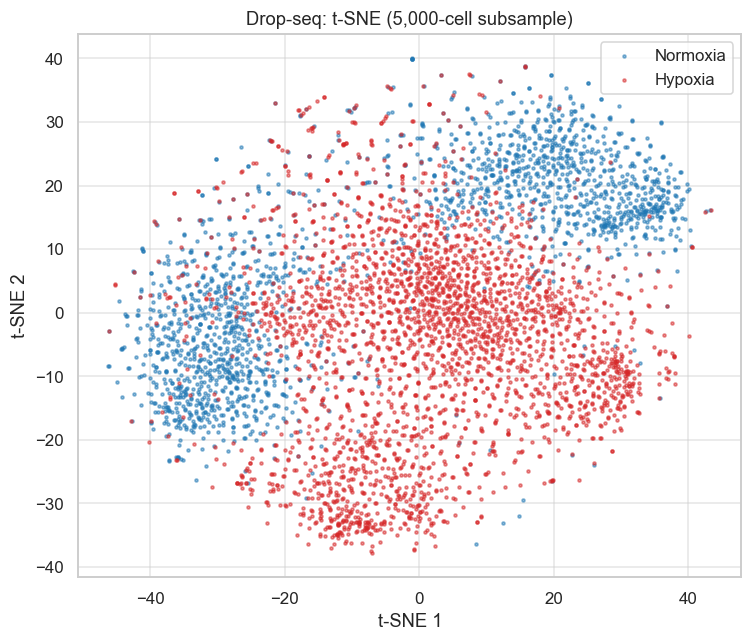

In [13]:
# UMAP — runs fine on 14k cells
X_pcs_ds = proj_ds[:, :50]  # already computed above

n_plots = 2 if HAS_UMAP else 1
fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 6), squeeze=False)

# t-SNE on 5,000-cell subsample
rng = np.random.default_rng(42)
sub_idx = rng.choice(len(X_pcs_ds), 5000, replace=False)
tsne_ds = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE,
               init='pca', learning_rate='auto').fit_transform(X_pcs_ds[sub_idx])

for c in ['Normoxia', 'Hypoxia']:
    mask = y_ds[sub_idx] == c
    axes[0,0].scatter(tsne_ds[mask, 0], tsne_ds[mask, 1], c=PALETTE[c], label=c,
                      s=4, alpha=0.5)
axes[0,0].set_title('Drop-seq: t-SNE (5,000-cell subsample)')
axes[0,0].set_xlabel('t-SNE 1'); axes[0,0].set_ylabel('t-SNE 2')
axes[0,0].legend()

if HAS_UMAP:
    umap_ds = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        random_state=RANDOM_STATE).fit_transform(X_pcs_ds)
    # Plot all cells
    for c in ['Normoxia', 'Hypoxia']:
        mask = y_ds == c
        axes[0,1].scatter(umap_ds[mask, 0], umap_ds[mask, 1], c=PALETTE[c], label=c,
                          s=3, alpha=0.4)
    axes[0,1].set_title('Drop-seq: UMAP (all 14,682 cells)')
    axes[0,1].set_xlabel('UMAP 1'); axes[0,1].set_ylabel('UMAP 2')
    axes[0,1].legend()

plt.tight_layout(); plt.savefig(OUTDIR / 'ds_02_embeddings.png', dpi=150); plt.show()

## 5. K-means clustering

In [14]:
km_ds = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE).fit(X_pcs_ds)
ari_ds = adjusted_rand_score(y_ds, km_ds.labels_)
nmi_ds = normalized_mutual_info_score(y_ds, km_ds.labels_)
cm_ds = pd.crosstab(pd.Series(y_ds, name='true'), pd.Series(km_ds.labels_, name='cluster'))
print(f'Drop-seq K-means (k=2):  ARI = {ari_ds:.3f},  NMI = {nmi_ds:.3f}')
print('Confusion:')
print(cm_ds.to_string())

# Silhouette over k (on a subsample — full silhouette on 14k cells is slow)
sub_idx = rng.choice(len(X_pcs_ds), 3000, replace=False)
sils_ds = []
for k in range(2, 8):
    km_k = KMeans(n_clusters=k, n_init=5, random_state=RANDOM_STATE).fit(X_pcs_ds)
    sils_ds.append(silhouette_score(X_pcs_ds[sub_idx], km_k.labels_[sub_idx]))
print(f'Silhouettes for k=2..7: {[round(s, 3) for s in sils_ds]}')
print(f'Best k by silhouette: {2 + int(np.argmax(sils_ds))}')

Drop-seq K-means (k=2):  ARI = 0.058,  NMI = 0.030
Confusion:
cluster      0     1
true                
Hypoxia   6352  2547
Normoxia  2982  2801
Silhouettes for k=2..7: [0.098, 0.063, 0.04, 0.039, 0.044, 0.043]
Best k by silhouette: 2


**Expected outcome:** ARI low (~0.05) — same lesson as Smart-seq, even more pronounced. With Drop-seq's extreme sparsity, the variance is so diffuse that unsupervised methods cannot identify the hypoxia signal at all. The technology is rich in cells but poor in per-cell information.

---
# Part C — Cross-technology comparison

The headline question: do the two technologies *see* the same biology, even if neither makes it the dominant axis of variation?

## 1. PC1 gene overlap

Genes that drive PC1 in Smart-seq vs Drop-seq. If both technologies put the same genes on PC1, they agree about what's most variable.

In [15]:
top_pc1_ss = set(loadings_ss['PC1'].abs().nlargest(50).index)
top_pc1_ds = set(loadings_ds['PC1'].abs().nlargest(50).index)
ss_genes = set(ss.index)
ds_genes = set(ds.index)
shared_all = ss_genes & ds_genes

print(f'Top-50 PC1 genes in Smart-seq: e.g. {sorted(list(top_pc1_ss))[:5]}')
print(f'Top-50 PC1 genes in Drop-seq:  e.g. {sorted(list(top_pc1_ds))[:5]}')
print(f'Intersection: {len(top_pc1_ss & top_pc1_ds)} genes ({sorted(top_pc1_ss & top_pc1_ds)})')
print(f'\nOverall shared gene pool: {len(shared_all)} / 3000 genes ({len(shared_all)/30:.0f}%)')

Top-50 PC1 genes in Smart-seq: e.g. ['ALDH1A1', 'AXL', 'BEST1', 'CD44', 'CDH13']
Top-50 PC1 genes in Drop-seq:  e.g. ['AHNAK', 'ATP5F1E', 'BCYRN1', 'CALR', 'ELOB']
Intersection: 0 genes ([])

Overall shared gene pool: 516 / 3000 genes (17%)


**Reading:** if the PC1-gene overlap is tiny (often only a handful), the two technologies disagree about what's most variable. This is because their *top-3000-most-variable* gene sets are largely different (only ~17% overlap), and the variance structure within each is different too. The biology lives in a different sub-space for each technology.

## 2. Log-fold-change concordance — the main result

For every gene shared between the two top-3000 sets, compute the log-fold-change of mean expression (Hypoxia − Normoxia) in each technology. Then ask: do the two technologies agree on *which genes go up in hypoxia*?

This is the most important plot of Phase 2 for the report. Even if PCA disagrees, logFC may agree — because logFC uses the labels directly.

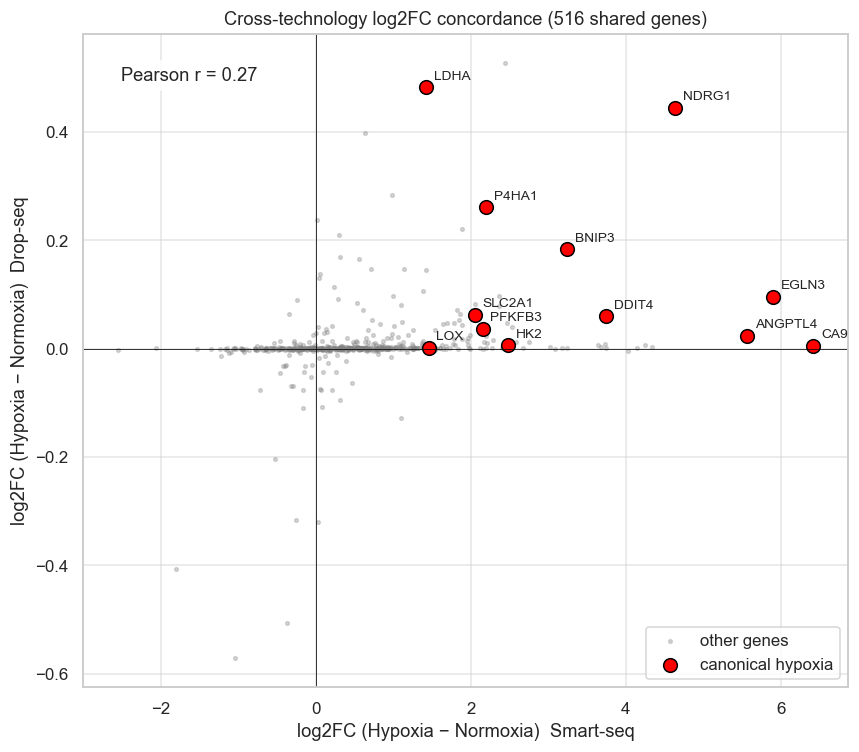


Pearson correlation of log2FC across technologies: 0.275

log2FC of canonical hypoxia markers:
  BNIP3       Smart-seq = +3.25   Drop-seq = +0.18
  PFKFB3      Smart-seq = +2.15   Drop-seq = +0.04
  CA9         Smart-seq = +6.42   Drop-seq = +0.01
  ANGPTL4     Smart-seq = +5.57   Drop-seq = +0.02
  LOX         Smart-seq = +1.45   Drop-seq = +0.00
  HK2         Smart-seq = +2.48   Drop-seq = +0.01
  LDHA        Smart-seq = +1.43   Drop-seq = +0.48
  DDIT4       Smart-seq = +3.75   Drop-seq = +0.06
  P4HA1       Smart-seq = +2.19   Drop-seq = +0.26
  SLC2A1      Smart-seq = +2.05   Drop-seq = +0.06
  NDRG1       Smart-seq = +4.64   Drop-seq = +0.44
  EGLN3       Smart-seq = +5.90   Drop-seq = +0.10


In [16]:
shared = sorted(shared_all)

def logfc(df, y, genes):
    hypo = df.loc[genes, y == 'Hypoxia']
    norm = df.loc[genes, y == 'Normoxia']
    return np.log2(hypo.mean(axis=1) + 1) - np.log2(norm.mean(axis=1) + 1)

fc_ss = logfc(ss, y_ss, shared)
fc_ds = logfc(ds, y_ds, shared)
r = np.corrcoef(fc_ss, fc_ds)[0, 1]

is_marker = pd.Index(shared).isin(MARKERS)

plt.figure(figsize=(8, 7))
plt.scatter(fc_ss[~is_marker], fc_ds[~is_marker], s=6, alpha=0.3, c='gray', label='other genes')
plt.scatter(fc_ss[is_marker], fc_ds[is_marker], s=80, c='red', edgecolors='black', label='canonical hypoxia')
for g, x, yval in zip(np.array(shared)[is_marker], fc_ss[is_marker], fc_ds[is_marker]):
    plt.annotate(g, (x, yval), fontsize=9, xytext=(5,5), textcoords='offset points')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('log2FC (Hypoxia − Normoxia)  Smart-seq')
plt.ylabel('log2FC (Hypoxia − Normoxia)  Drop-seq')
plt.title(f'Cross-technology log2FC concordance ({len(shared)} shared genes)')
plt.text(0.05, 0.95, f'Pearson r = {r:.2f}', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
plt.legend(loc='lower right')
plt.tight_layout(); plt.savefig(OUTDIR / 'cross_01_logfc.png', dpi=150); plt.show()

print(f'\nPearson correlation of log2FC across technologies: {r:.3f}')
print('\nlog2FC of canonical hypoxia markers:')
for m in MARKERS:
    if m in shared:
        print(f'  {m:10s}  Smart-seq = {fc_ss[m]:+.2f}   Drop-seq = {fc_ds[m]:+.2f}')

**This is the key finding to write up in the report.** Two things to observe:

1. **Positive Pearson r** (~0.3): the two technologies *do* agree about the direction of hypoxia regulation, on average. Genes going up in Smart-seq tend to go up in Drop-seq too — even if the magnitudes are very different.

2. **Canonical hypoxia markers (red dots) are firmly in the upper-right quadrant** in Smart-seq (large positive logFC), but compressed near zero in Drop-seq. The biology is preserved in *direction*, but Drop-seq's sparsity drastically dampens the *magnitude* — when most cells have 0 reads for any given gene, the mean shifts very slowly even for a strongly responsive gene.

**Implication for Phase 3:** a classifier trained on Smart-seq learns large coefficients on hypoxia genes. When applied to Drop-seq, the same genes have much smaller observed values, so the linear score will be tiny and uninformative. **Direct cross-technology transfer will not work without rescaling** (per-feature z-score, rank transform, or binarisation). This is exactly the cross-technology challenge the project hints at.

## 3. Top differential genes — Venn-style overlap

In [17]:
TOP_N = 30
top_up_ss = set(fc_ss.nlargest(TOP_N).index)
top_up_ds = set(fc_ds.nlargest(TOP_N).index)
top_dn_ss = set(fc_ss.nsmallest(TOP_N).index)
top_dn_ds = set(fc_ds.nsmallest(TOP_N).index)

print(f'Top-{TOP_N} UP in hypoxia:')
print(f'  Only Smart-seq: {len(top_up_ss - top_up_ds)}')
print(f'  Both:           {len(top_up_ss & top_up_ds)} → {sorted(top_up_ss & top_up_ds)}')
print(f'  Only Drop-seq:  {len(top_up_ds - top_up_ss)}')
print(f'\nTop-{TOP_N} DOWN in hypoxia:')
print(f'  Both: {len(top_dn_ss & top_dn_ds)} → {sorted(top_dn_ss & top_dn_ds)[:10]}{"..." if len(top_dn_ss & top_dn_ds) > 10 else ""}')

Top-30 UP in hypoxia:
  Only Smart-seq: 26
  Both:           4 → ['BNIP3', 'EGLN3', 'IGFBP3', 'NDRG1']
  Only Drop-seq:  26

Top-30 DOWN in hypoxia:
  Both: 2 → ['AKR1C1', 'AKR1C2']


**Reading:** the overlap in top-UP genes is small (often only 3-5 genes), but those few are typically the canonical hypoxia markers (`BNIP3, EGLN3, NDRG1, IGFBP3`, etc.). This is the "core hypoxia signature" — small but reliable — that any cross-technology classifier will rely on.

---
## Summary — Phase 2 findings

1. **Smart-seq.** PC1 captures only a small fraction of variance (~5%) and is dominated by **epithelial-subtype heterogeneity** (keratins, mucins), not hypoxia. K-means at k=2 gives ARI ≈ 0 against condition — clustering finds a real two-cluster structure (silhouette peaks at k=2) but it is sub-population structure orthogonal to oxygen treatment. The hypoxia signal exists on lower-order PCs.

2. **Drop-seq.** Even more extreme. PC1 < 1% of variance (97% sparsity diffuses variance everywhere), top loadings are ribosomal/mitochondrial genes (technical signal, not biology). K-means ARI ≈ 0.05.

3. **Unsupervised methods do not recover hypoxia in either technology.** This is consistent with the short exposure (24h) and the cell-population heterogeneity of HCC1806. It does **not** mean the hypoxia signal is absent — it means it is not the *dominant* signal.

4. **The biology IS preserved, but only when we use labels.** Computing log-fold-changes (Hypoxia − Normoxia) on the 516 shared genes reveals a positive correlation between technologies (Pearson r ≈ 0.3), and canonical hypoxia markers (`DDIT4, ANGPTL4, NDRG1, EGLN3, CA9, BNIP3`) are upregulated in hypoxia in both — confirming the biology is conserved across technologies in direction.

5. **However, Drop-seq's logFC magnitudes are much smaller** (CA9 logFC: +6.4 in Smart-seq vs +0.01 in Drop-seq). Sparsity drastically compresses the dynamic range. This means **direct cross-technology transfer of a linear classifier will not work** — features have completely different scales. Rescaling, rank transformation, or binarisation will be required.

6. **Methodological takeaway.** Unsupervised structure ≠ the structure we care about. Clustering finds the strongest axis of variation, which may not align with labels. Supervised methods exploit labels directly and can find subtler signals — which is exactly the right next step.

**Decision for Phase 3 (supervised):** within each technology, fit logistic regression (L1, L2), SVM, Random Forest, Gradient Boosting; use stratified CV; report ROC-AUC, accuracy, F1. For cross-technology transfer, work on the 516-gene intersection and compare strategies: raw, per-feature z-score, rank transform, binarisation. Produce test-set predictions for both `_test_anonim` files.